# Mobility and Economy Analysis in Latin American Cities

This notebook is configured to run locally in VS Code using the processed project dataset.

The original learning-platform raw files are not included, so the analysis starts from:

`../data/processed/ladb_mobility_economy_2024_clean.csv`

## 1. Setup

Import libraries and configure project paths using relative locations, so the notebook works after cloning or downloading the repository.

In [36]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "ladb_mobility_economy_2024_clean.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_PATH}")

Project root: c:\Users\Joel_\OneDrive\Imágenes\Escritorio\Recordatorios_de_Data_Analist\recomendaciones para el cv y carta de presentacion\proyectos\ladb_mobility_economy_vscode_ready\ladb_mobility_economy_vscode_ready
Dataset path: c:\Users\Joel_\OneDrive\Imágenes\Escritorio\Recordatorios_de_Data_Analist\recomendaciones para el cv y carta de presentacion\proyectos\ladb_mobility_economy_vscode_ready\ladb_mobility_economy_vscode_ready\data\processed\ladb_mobility_economy_2024_clean.csv


## 2. Load the dataset

Load the clean dataset and validate the columns required for the analysis.

In [37]:
required_columns = {
    "city", "country", "year", "JamsDelay", "TrafficIndexLive",
    "JamsLengthInKms", "JamsCount", "MinsDelay",
    "TravelTimeLivePer10KmsMins", "TravelTimeHistoricPer10KmsMins",
    "city_gdp_capita", "unemployment_pct", "pm25", "population"
}

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}. "
        "Place ladb_mobility_economy_2024_clean.csv in data/processed/."
    )

data = pd.read_csv(DATA_PATH)
missing_columns = required_columns.difference(data.columns)

if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

print(f"Rows: {data.shape[0]:,}")
print(f"Columns: {data.shape[1]:,}")
data.head()

Rows: 15
Columns: 14


,city,country,year,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,MinsDelay,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,city_gdp_capita,unemployment_pct,pm25,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,16.8,6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,17.6,11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,12.8,4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,14.5,15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,13.5,3700000.0


## 3. Dataset overview

In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   city                            15 non-null     object 
 1   country                         15 non-null     object 
 2   year                            15 non-null     int64  
 3   JamsDelay                       15 non-null     float64
 4   TrafficIndexLive                15 non-null     float64
 5   JamsLengthInKms                 15 non-null     float64
 6   JamsCount                       15 non-null     float64
 7   MinsDelay                       15 non-null     float64
 8   TravelTimeLivePer10KmsMins      15 non-null     float64
 9   TravelTimeHistoricPer10KmsMins  15 non-null     float64
 10  city_gdp_capita                 15 non-null     float64
 11  unemployment_pct                15 non-null     float64
 12  pm25                            15 non

In [39]:
summary = data.describe(include="all").transpose()
summary

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
city,15,15,belo-horizonte,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,15,7,BRA,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,15.0,NaN,NaN,NaN,2024.0,0.0,2024.0,2024.0,2024.0,2024.0,2024.0
JamsDelay,15.0,NaN,NaN,NaN,629.517204,783.063726,50.201092,107.165938,263.047879,841.079053,2833.057892
TrafficIndexLive,15.0,NaN,NaN,NaN,22.102749,7.480396,11.25822,17.351054,20.155352,26.020448,37.614273
JamsLengthInKms,15.0,NaN,NaN,NaN,87.858914,105.159497,6.369201,17.611311,44.038129,105.301307,389.239265
JamsCount,15.0,NaN,NaN,NaN,144.324391,168.162789,14.160332,30.250647,68.805422,183.274409,594.969392
MinsDelay,15.0,NaN,NaN,NaN,0.61827,0.618267,0.072539,0.166703,0.393442,0.878235,1.855542
TravelTimeLivePer10KmsMins,15.0,NaN,NaN,NaN,19.034347,3.270021,13.338658,17.084315,18.304538,20.451702,25.674261
TravelTimeHistoricPer10KmsMins,15.0,NaN,NaN,NaN,18.416077,2.80672,13.145216,16.745914,17.817311,19.81318,24.167956


## 4. Top cities by traffic delay

In [40]:
top_delay = (
    data.sort_values("JamsDelay", ascending=False)
    [["city", "country", "JamsDelay", "TrafficIndexLive", "city_gdp_capita", "unemployment_pct"]]
    .head(10)
)

top_delay

,city,country,JamsDelay,TrafficIndexLive,city_gdp_capita,unemployment_pct
7,mexico-city,MEX,2833.057892,34.218190,21111.0,3.2
14,sao-paulo,BRA,1729.189270,26.877932,14703.0,8.5
1,bogota,COL,1141.552364,37.614273,11442.0,10.0
6,lima,PER,1052.292789,31.031277,13472.0,6.5
13,santiago,CHL,629.865318,20.155352,2277.0,7.8
3,buenos-aires,ARG,571.089593,17.756012,18117.0,7.2
11,rio-de-janeiro,BRA,466.064706,25.162963,13349.0,9.2
0,belo-horizonte,BRA,263.047879,19.428946,11124.0,9.5
4,curitiba,BRA,183.469274,14.954545,12381.0,8.2
9,porto-alegre,BRA,139.382830,17.687254,11801.0,8.7


## 5. Traffic delay distribution

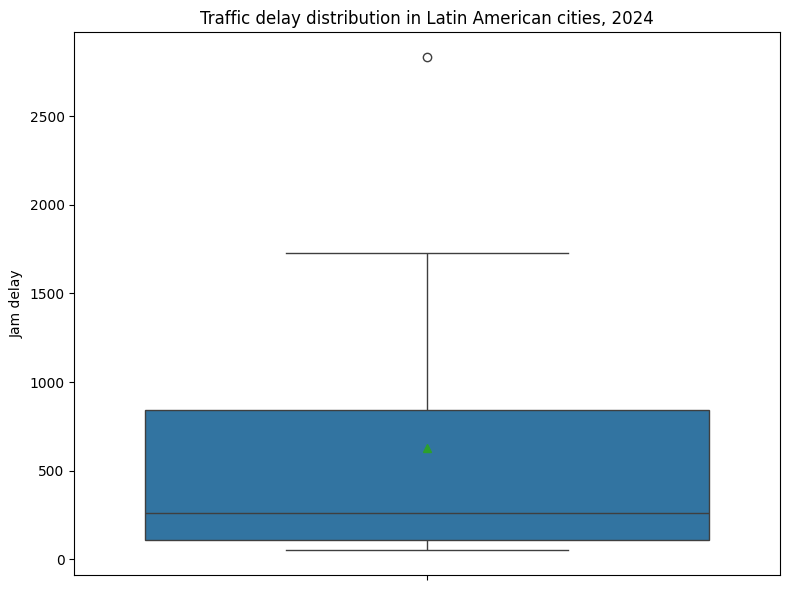

In [41]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=data, y="JamsDelay", showmeans=True)
plt.title("Traffic delay distribution in Latin American cities, 2024")
plt.ylabel("Jam delay")
plt.tight_layout()
plt.show()

## 6. GDP per capita distribution

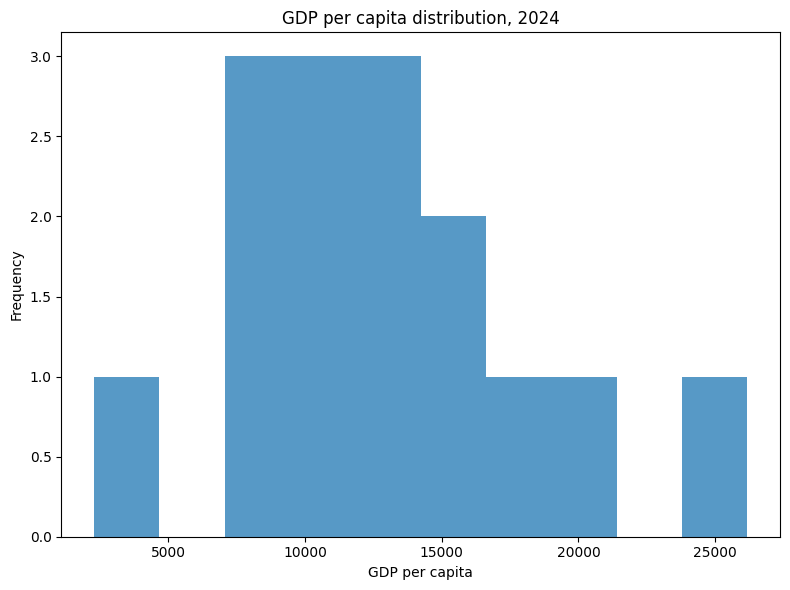

In [42]:
plt.figure(figsize=(8, 6))
plt.hist(data["city_gdp_capita"], bins=10, alpha=0.75)
plt.title("GDP per capita distribution, 2024")
plt.xlabel("GDP per capita")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 7. Traffic delay vs GDP per capita

<Figure size 1200x600 with 0 Axes>

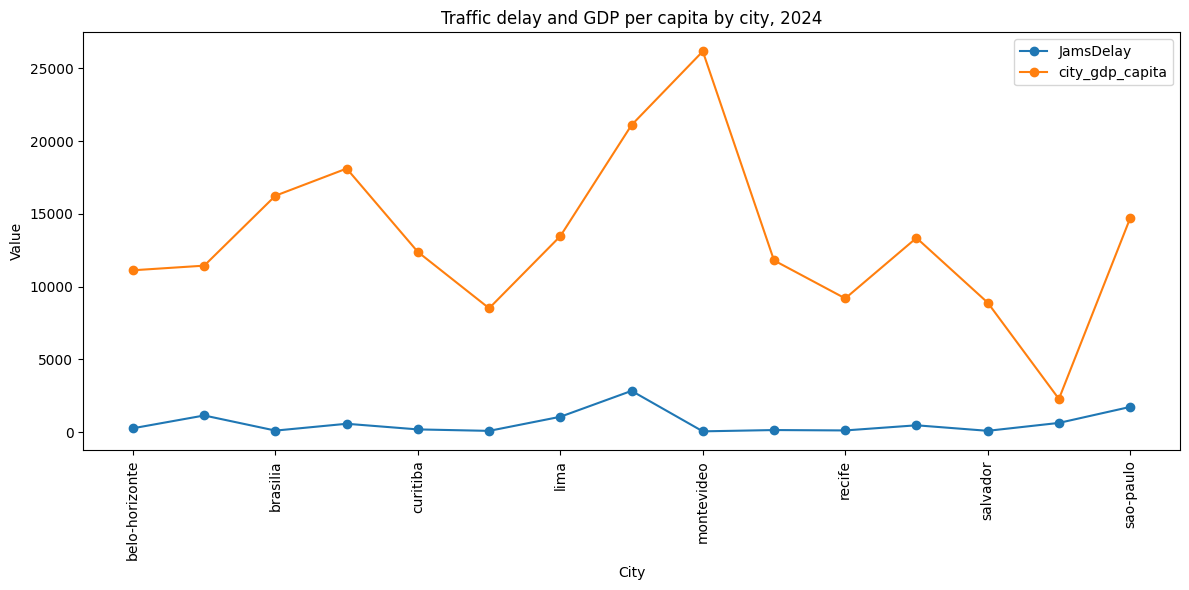

In [43]:
# Compare traffic delay and GDP per capita by city
plot_data = data.sort_values("city")

plt.figure(figsize=(12, 6))

plot_data.plot(
    x="city",
    y=["JamsDelay", "city_gdp_capita"],
    marker="o",
    figsize=(12, 6)
)

plt.title("Traffic delay and GDP per capita by city, 2024")
plt.xlabel("City")
plt.ylabel("Value")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 8. Correlation matrix

In [44]:
numeric_columns = [
    "JamsDelay", "TrafficIndexLive", "JamsLengthInKms", "JamsCount",
    "MinsDelay", "TravelTimeLivePer10KmsMins", "TravelTimeHistoricPer10KmsMins",
    "city_gdp_capita", "unemployment_pct", "pm25", "population"
]

correlation_matrix = data[numeric_columns].corr()
correlation_matrix

,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,MinsDelay,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,city_gdp_capita,unemployment_pct,pm25,population
JamsDelay,1.000000,0.765017,0.992445,0.994274,0.876811,0.568016,0.468633,0.282975,-0.686956,0.767783,0.878525
TrafficIndexLive,0.765017,1.000000,0.719139,0.736544,0.892927,0.838366,0.780058,0.056001,-0.293692,0.630863,0.647225
JamsLengthInKms,0.992445,0.719139,1.000000,0.993273,0.826939,0.489129,0.387710,0.292821,-0.692595,0.765272,0.903054
JamsCount,0.994274,0.736544,0.993273,1.000000,0.845108,0.531094,0.432599,0.267895,-0.665562,0.814078,0.907596
MinsDelay,0.876811,0.892927,0.826939,0.845108,1.000000,0.790805,0.701061,0.237215,-0.592742,0.643116,0.707157
TravelTimeLivePer10KmsMins,0.568016,0.838366,0.489129,0.531094,0.790805,1.000000,0.990869,0.091659,-0.185823,0.443928,0.425790
TravelTimeHistoricPer10KmsMins,0.468633,0.780058,0.387710,0.432599,0.701061,0.990869,1.000000,0.054535,-0.085927,0.375541,0.340301
city_gdp_capita,0.282975,0.056001,0.292821,0.267895,0.237215,0.091659,0.054535,1.000000,-0.514407,-0.167475,0.276688
unemployment_pct,-0.686956,-0.293692,-0.692595,-0.665562,-0.592742,-0.185823,-0.085927,-0.514407,1.000000,-0.333479,-0.572405
pm25,0.767783,0.630863,0.765272,0.814078,0.643116,0.443928,0.375541,-0.167475,-0.333479,1.000000,0.797065


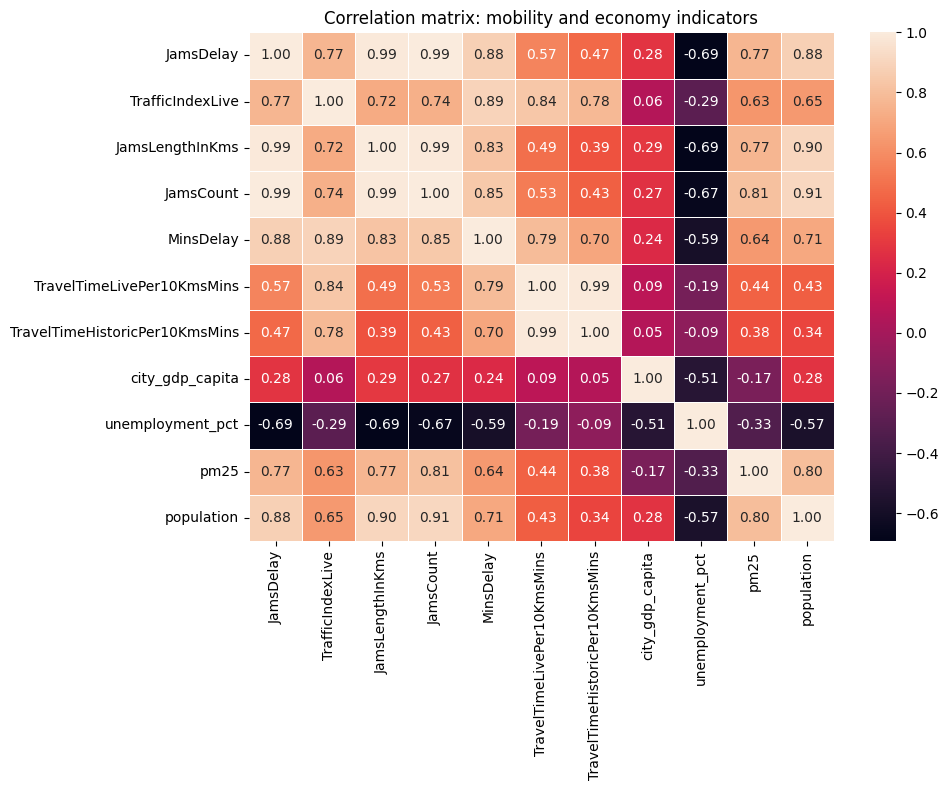

In [45]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation matrix: mobility and economy indicators")
plt.tight_layout()
plt.show()

## 9. Export final dataset

The processed dataset is saved again in `outputs/` so results are easy to find after running the notebook.

In [46]:
output_path = OUTPUT_DIR / "ladb_mobility_economy_2024_clean.csv"
data.to_csv(output_path, index=False)
print(f"Saved clean dataset to: {output_path}")

Saved clean dataset to: c:\Users\Joel_\OneDrive\Imágenes\Escritorio\Recordatorios_de_Data_Analist\recomendaciones para el cv y carta de presentacion\proyectos\ladb_mobility_economy_vscode_ready\ladb_mobility_economy_vscode_ready\outputs\ladb_mobility_economy_2024_clean.csv


## 10. Conclusions

- The project runs locally from a processed dataset because the original course-platform raw files are not available.
- Traffic delay varies widely across the selected cities.
- The visual analysis can be used to explore associations between congestion, GDP per capita, unemployment, air quality and population.
- These results should be interpreted as exploratory relationships, not as causal effects.